# Task 2 — Time Series Forecasting Models

**GMF Investments · Week 9**

Forecast **TSLA** Adjusted Close. This notebook covers data preparation
(chronological split) and the **ARIMA/SARIMA** model; the LSTM and the final
model comparison follow in later sections.

**Split (critical for time series — no shuffling):** train 2015–2024, test 2025–2026.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, forecasting as fc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Prepare Data — Chronological Train/Test Split

Full : 2015-01-02 -> 2026-06-29  (n=2888)
Train: 2015-01-02 -> 2024-12-31  (n=2516)
Test : 2025-01-02 -> 2026-06-29  (n=372)


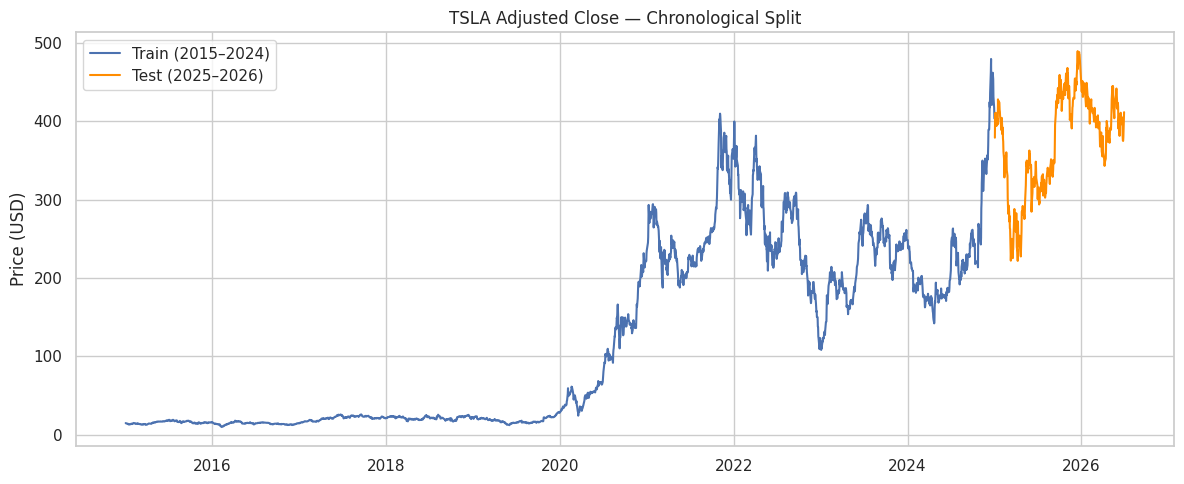

In [2]:
target = fc.load_target()  # TSLA Adj Close
train, test = fc.chronological_split(target)

print(f"Full : {target.index.min().date()} -> {target.index.max().date()}  (n={len(target)})")
print(f"Train: {train.index.min().date()} -> {train.index.max().date()}  (n={len(train)})")
print(f"Test : {test.index.min().date()} -> {test.index.max().date()}  (n={len(test)})")

fig, ax = plt.subplots()
ax.plot(train.index, train, label="Train (2015–2024)")
ax.plot(test.index, test, label="Test (2025–2026)", color="darkorange")
ax.set_title("TSLA Adjusted Close — Chronological Split")
ax.set_ylabel("Price (USD)"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "07_train_test_split.png", dpi=120)
plt.show()

## 2. Identify Order — ACF / PACF
Task 1 showed the price level is **non-stationary** (ADF p > 0.05), so we
difference once (`d = 1`) and inspect the ACF/PACF of the differenced series to
sanity-check candidate AR (`p`, from PACF) and MA (`q`, from ACF) orders. This
corroborates the automated search below.

ADF p-value, differenced train: 8.734e-17  (stationary => d=1)


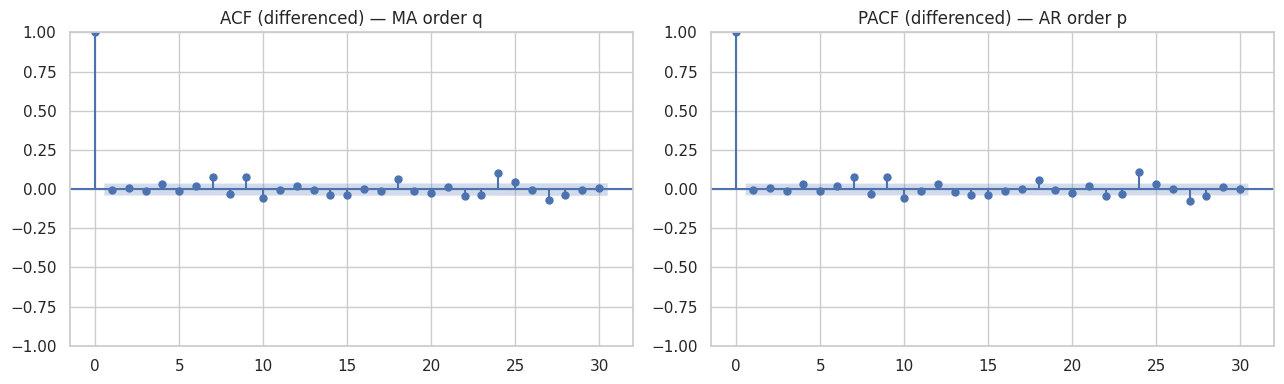

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

diff = train.diff().dropna()
print(f"ADF p-value, differenced train: {adfuller(diff)[1]:.3e}  (stationary => d=1)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(diff, lags=30, ax=axes[0]); axes[0].set_title("ACF (differenced) — MA order q")
plot_pacf(diff, lags=30, ax=axes[1], method="ywm"); axes[1].set_title("PACF (differenced) — AR order p")
fig.tight_layout(); fig.savefig(FIG_DIR / "08_acf_pacf.png", dpi=120)
plt.show()

## 3. Auto-ARIMA Grid Search
`pmdarima.auto_arima` searches (p, d, q) by AIC. Daily equity prices have no
fixed calendar seasonality, so we fit **non-seasonal** ARIMA as the primary
model (a weekly `m=5` SARIMA on ~2,500 points is expensive and rarely improves
on this data). `d` is selected automatically and is expected to be 1, matching
the differencing above.

In [4]:
arima = fc.fit_auto_arima(train, seasonal=False, trace=True)
print("\nSelected order (p, d, q):", arima.order)
print(arima.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.10 sec


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.04 sec


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.20 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.564 seconds

Selected order (p, d, q): (0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        14:22:52   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.

## 4. Forecast the Test Period
Static multi-step forecast over the full test horizon with 95% confidence intervals.

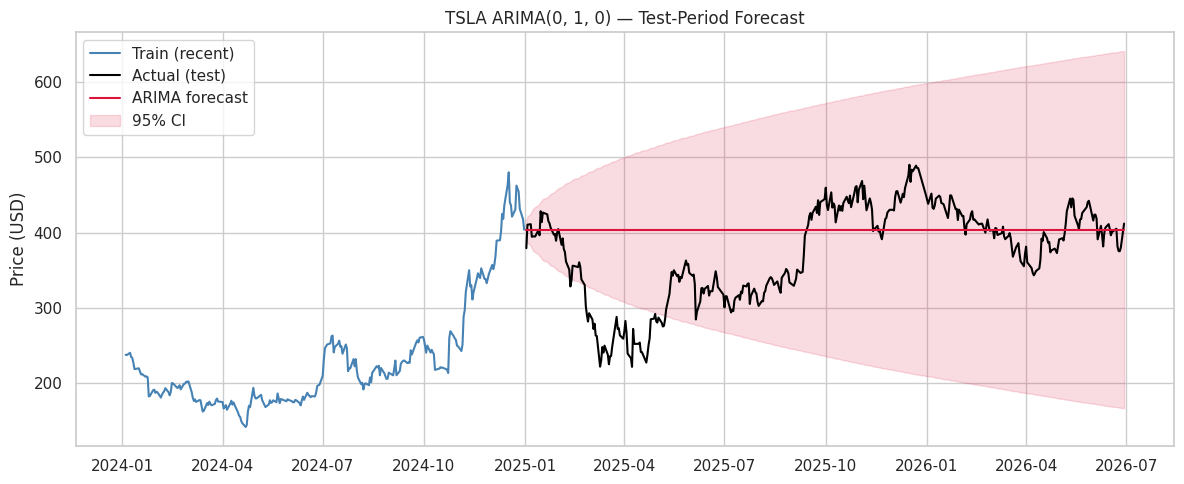

In [5]:
fc_mean, conf = fc.arima_forecast(arima, n_periods=len(test), index=test.index)

fig, ax = plt.subplots()
ax.plot(train.index[-250:], train.iloc[-250:], label="Train (recent)", color="steelblue")
ax.plot(test.index, test, label="Actual (test)", color="black")
ax.plot(fc_mean.index, fc_mean, label="ARIMA forecast", color="crimson")
ax.fill_between(conf.index, conf["lower"], conf["upper"], color="crimson", alpha=0.15, label="95% CI")
ax.set_title(f"TSLA ARIMA{arima.order} — Test-Period Forecast")
ax.set_ylabel("Price (USD)"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "09_arima_forecast.png", dpi=120)
plt.show()

## 5. Evaluate — MAE / RMSE / MAPE

In [6]:
arima_metrics = fc.evaluate(test.values, fc_mean.values)
print("ARIMA test metrics:")
for k, v in arima_metrics.items():
    print(f"  {k}: {v:.4f}")

# Persist for the later model-comparison table.
metrics_df = pd.DataFrame({f"ARIMA{arima.order}": arima_metrics}).T
config.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(config.PROCESSED_DIR / "model_metrics.csv")
metrics_df.round(4)

ARIMA test metrics:
  MAE: 54.4412
  RMSE: 70.5393
  MAPE: 17.2407


,MAE,RMSE,MAPE
"ARIMA(0, 1, 0)",54.4412,70.5393,17.2407


## Notes

- **Order = ARIMA(0,1,0) — a random walk.** `auto_arima` minimized AIC and found no AR or MA terms improve on differencing alone. This is the classic **Efficient Market Hypothesis** result: the best statistical guess for tomorrow's price is today's price. `d=1` matches the differencing needed for stationarity (Task 1).
- **Consequence:** the static multi-step forecast is a flat line at the last observed price, and the 95% CI fans out as √horizon — quantifying how quickly certainty decays. MAPE ≈ 17% over the ~18-month test window reflects TSLA's large drift away from that flat forecast.
- **Seasonality:** No fixed calendar seasonality in daily equity prices, so a non-seasonal ARIMA is used; SARIMA `(P, D, Q, m)` would be the extension for data with a repeating cycle.
- **Next:** the LSTM can, in principle, adapt to trend/momentum a random walk cannot — the comparison (MAE/RMSE/MAPE) will show whether that holds here.